In [10]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [11]:
RndmGraph = nx.random_geometric_graph(6, 1, dim=2, seed=42)
#RndmGraph = nx.barabasi_albert_graph(6, 1)

In [12]:
G = nx.Graph(RndmGraph) #creates graph copy
print(list(G.nodes()))

mappingT = {i:("T", i)for i in G.nodes()} # map T to Terminals
G = nx.relabel_nodes(G, mappingT)         


TerminalArray = list(G.nodes()) 
TerminalArrayLength = len(TerminalArray)

print(f"TerminalArray: {TerminalArray}")
print(f"TerminalArrayLength: {TerminalArrayLength}")


[0, 1, 2, 3, 4, 5]
TerminalArray: [('T', 0), ('T', 1), ('T', 2), ('T', 3), ('T', 4), ('T', 5)]
TerminalArrayLength: 6


In [ ]:
# first idea for creating a list of all Topos was scraped 
# as i coulndt find a good way to generate all "full" Steiner topologies for a Graph with Terminals

i=0
while i < TerminalArrayLength:   #with = its of by 1 error!
    if (TerminalArrayLength % 2 == 0):
        print(i)
        i += 1
    else:
        print("odd",i)
        print("odd",TerminalArray[i])
        i += 1


In [ ]:
# G.nodes[0]
# G.edges()
# G.edges[0, 1]

node = list(G.nodes)[0]
print(f"Node: {node}")

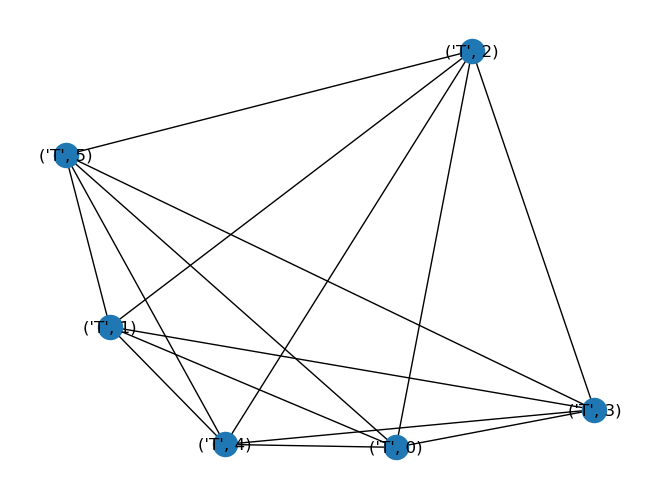

In [13]:
#plot graph (w/o steiner points)
pos = nx.get_node_attributes(G, "pos") # works only with generated geo graphs or pos added to nodes

nx.draw(G, pos, with_labels=True)
plt.show()

In [14]:
#TOPO algorithm

#find all full Steiner topos. (Terminals degree 1, All Steiner points degree 3, tree = n-2 Steiner points))
#Labeling: ("T", i) for terminals, ("S", j) for Steiner points

def FullSteinerTopologies(TerminalArray):
    n = len(TerminalArray) #amount of terminals

    #if less then 3 terminals, no Steiner point possible
    if n < 3:                                 
        Start = nx.Graph()
        Start.add_nodes_from(TerminalArray)
        if n == 2:
            Start.add_edge(TerminalArray[0], TerminalArray[1])
        return [Start]


    # connect first 3 terminals to S0 point
    Start = nx.Graph()
    Start.add_edges_from([(TerminalArray[k], ("S", 0)) for k in range(3)])
    Topologies = [Start]

    # insert every new terminal into every edge of every topology found so far:
    # cut the edge put a new Steiner point in the middle and  hang the new terminal on it
    for k in range(3, n):
        Grown = [] # start with an empty list for the new topologies
        for T in Topologies:
            for (u, v) in T.edges():    # loop over all edges (u, v) in previous topology T
                New = T.copy()                # copy the topology T to a new graph New
                S = ("S", k - 2)              # add ne steiner point (k -2 because first 3 terminals are connected to S0)
                New.remove_edge(u, v)         # remove the replaced edge 
                New.add_edges_from([(u, S), (S, v), (S, TerminalArray[k])]) # add new edges for new steiner point and terminal
                Grown.append(New)
       
        Topologies = Grown
    return Topologies

In [15]:
#algorithm execution and output
Topologies = FullSteinerTopologies(TerminalArray)
n = len(TerminalArray)
edges = Topologies[0].edges()
AllEdgeTopos = [T.edges() for T in Topologies]

print("All Edge Topos:")
for T in Topologies:
    print(f"Topo: {Topologies.index(T)}", " "
        .join(
        f"({u[0]}{u[1]}-{v[0]}{v[1]})"
        for u, v in T.edges()
        )
)

expected = 1
for f in range(1, 2 * n - 4, 2):
    expected *= f

print("Edges ", list(Topologies[0].edges()))
print("terminals ", n)
print("topologies:", len(Topologies), "expected:", expected)

All Edge Topos:
Topo: 0 (T0-S3) (S0-T1) (S0-T2) (S0-S1) (S1-T3) (S1-S2) (S2-T4) (S2-S3) (S3-T5)
Topo: 1 (T0-S2) (S0-T2) (S0-S1) (S0-S3) (T1-S3) (S1-T3) (S1-S2) (S2-T4) (S3-T5)
Topo: 2 (T0-S2) (S0-T1) (S0-S1) (S0-S3) (T2-S3) (S1-T3) (S1-S2) (S2-T4) (S3-T5)
Topo: 3 (T0-S2) (S0-T1) (S0-T2) (S0-S3) (S1-T3) (S1-S2) (S1-S3) (S2-T4) (S3-T5)
Topo: 4 (T0-S2) (S0-T1) (S0-T2) (S0-S1) (S1-S2) (S1-S3) (T3-S3) (S2-T4) (S3-T5)
Topo: 5 (T0-S2) (S0-T1) (S0-T2) (S0-S1) (S1-T3) (S1-S3) (S2-T4) (S2-S3) (S3-T5)
Topo: 6 (T0-S2) (S0-T1) (S0-T2) (S0-S1) (S1-T3) (S1-S2) (S2-S3) (T4-S3) (S3-T5)
Topo: 7 (T0-S3) (S0-T2) (S0-S1) (S0-S2) (T1-S2) (S1-T3) (S1-S3) (S2-T4) (S3-T5)
Topo: 8 (T0-S1) (S0-S1) (S0-S2) (S0-S3) (T1-S2) (T2-S3) (S1-T3) (S2-T4) (S3-T5)
Topo: 9 (T0-S1) (S0-T2) (S0-S2) (S0-S3) (T1-S2) (S1-T3) (S1-S3) (S2-T4) (S3-T5)
Topo: 10 (T0-S1) (S0-T2) (S0-S1) (S0-S3) (T1-S2) (S1-T3) (S2-T4) (S2-S3) (S3-T5)
Topo: 11 (T0-S1) (S0-T2) (S0-S1) (S0-S2) (T1-S3) (S1-T3) (S2-T4) (S2-S3) (S3-T5)
Topo: 12 (T0-S1) (S0-T